Example of how to parse the files and load data in dataframes.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [2]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

C:\Users\Filip\OneDrive\Documents\GitHub\Examensarbete\data


In [3]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [4]:
# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)
noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [5]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_0
---------------------------------------------
Loading walking data for subject:  subject_1
---------------------------------------------
Loading walking data for subject:  subject_10
Loading test:  10_0
Loading test:  10_1
Loading test:  10_10
Loading test:  10_11
Loading test:  10_12
Loading test:  10_13
Loading test:  10_14
Loading test:  10_15
Loading test:  10_16
Loading test:  10_17
Loading test:  10_2
Loading test:  10_3
Loading test:  10_4
Loading test:  10_5
Loading test:  10_6
Loading test:  10_7
Loading test:  10_8
Loading test:  10_9
---------------------------------------------
Loading walking data for subject:  subject_11
Loading test:  11_0
Loading test:  11_1
Loading test:  11_10
Loading test:  11_11
Loading test:  11_12
Loading test:  11_13
Loading test:  11_14
Loading test:  11_15
Loading test:  11_2
Loading test:  11_3
Loading test:  11_4
Loading test:  11_5
Loading test:  11_6


In [6]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
print("Events: ", selection[0].events.head())
print("Motion: ", selection[0].motion.head())
print("Orientation: ", selection[0].orientation.head())
print("Positions: ", selection[0].positions.head())
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  10_0
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0     1481.0  361167.000055
Motion:     Unnamed: 0     ms  accelX  accelY  accelZ  accelWithGX  accelWithGY  \
0           0  178.0    -0.1     0.0     0.2         -0.2          3.2   
1           1  192.0    -0.1     0.0     0.3         -0.2          3.2   
2           2  200.0    -0.1    -0.1     0.3         -0.3          3.1   
3           3  218.0    -0.1    -0.2     0.4         -0.2          2.9   
4           4  234.0    -0.1    -0.2     0.4         -0.3          2.9   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0          9.4          -2.6          0.8           3.3        16  
1          9.4          -2.6          0.8           3.3        16  
2          9.6          -2.8         -1.4           3.4        16  
3          9.7          -1.6         -2.1           2.4        16  
4          9.8           0.5         -3.4          

Total distance traveled for 10_0: 443.74 meters


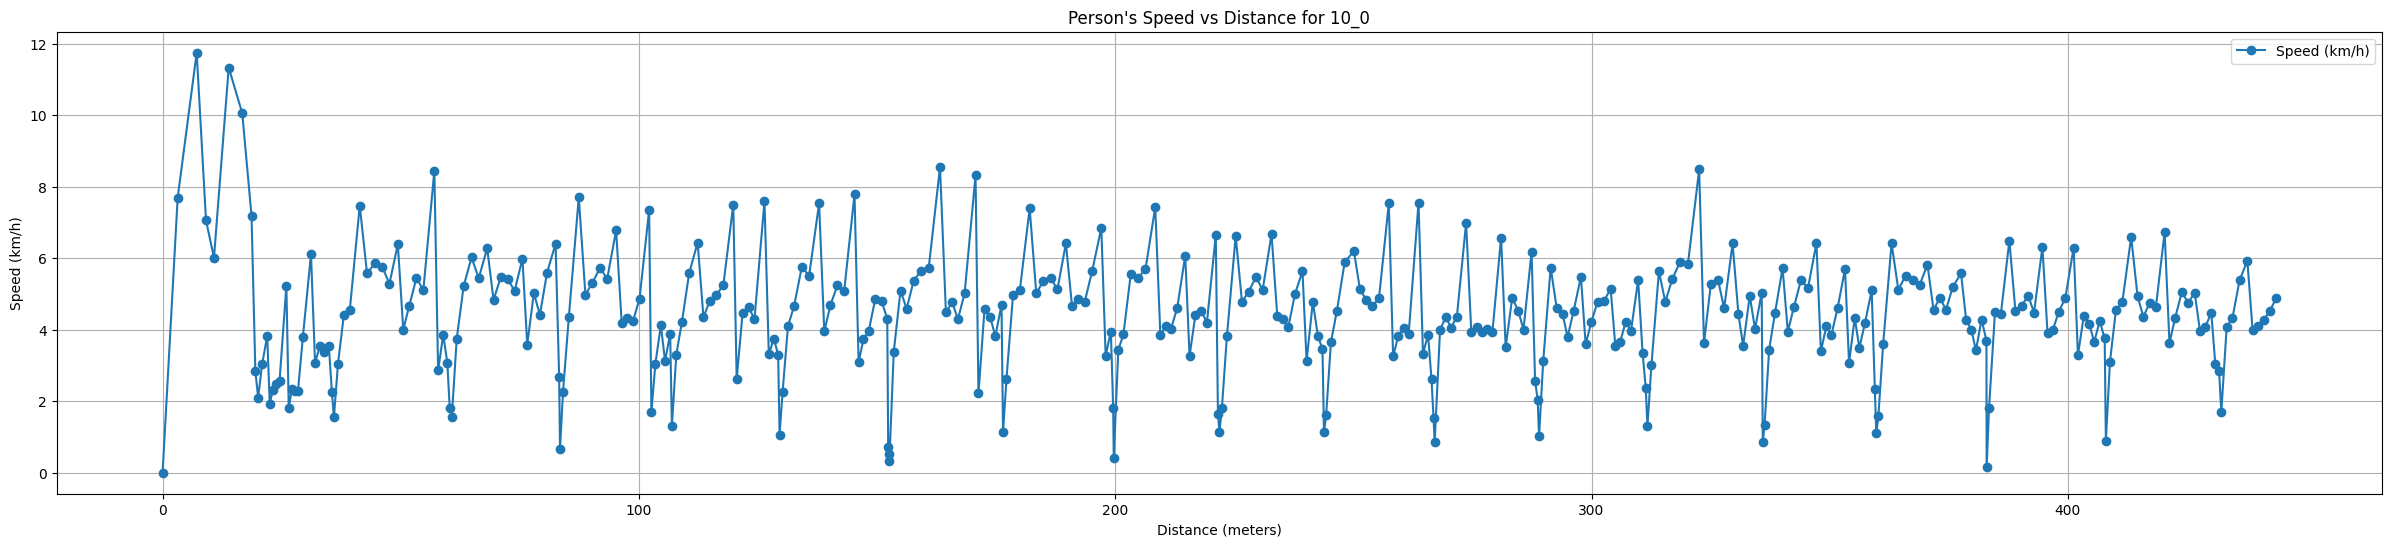

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def haversine(lat1, lon1, lat2, lon2):
    """Calculates the distance between two latitude/longitude points in meters."""
    R = 6371000  # Earth's radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

selection = selection[:12]  # Select the first test for demonstration

for test in selection:
    positions_data = test.positions

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points
    positions_data['distance_m'] = [0] + [
        haversine(positions_data['latitude'][i-1], positions_data['longitude'][i-1],
                  positions_data['latitude'][i], positions_data['longitude'][i])
        for i in range(1, len(positions_data))
    ]

    # Calculate total distance traveled
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate speed (m/s) and convert to km/h
    positions_data['speed_kmph'] = (positions_data['distance_m'] / positions_data['time_s'].diff().fillna(1)) * 3.6

    # Create plot for speed vs distance
    plt.figure(figsize=(30, 6))
    plt.plot(positions_data['distance_m'].cumsum(), positions_data['speed_kmph'], marker='o', linestyle='-', label='Speed (km/h)')
    plt.xlabel('Distance (meters)')
    plt.ylabel('Speed (km/h)')
    plt.title(f"Person's Speed vs Distance for {test.filename}")
    plt.legend()
    plt.grid()
    plt.show()

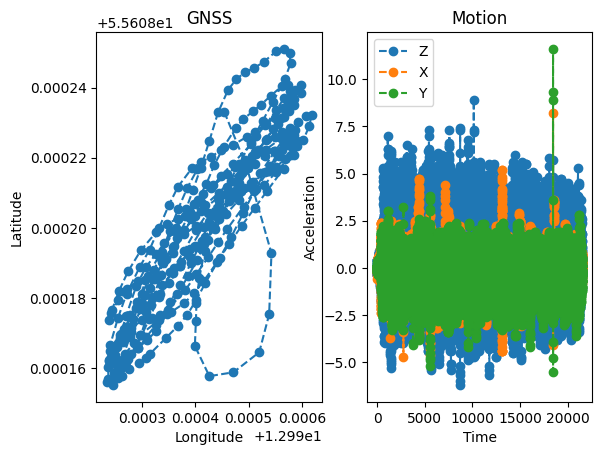

In [8]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()


In [9]:
metadata.head()

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,gt_type,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app
0,0,0,0_0,True,623,False,True,"Apple iPhone11,8",598.373421,755.0,...,final,UK,True,368,NaN,0.304348,0.380435,1.692935,hand held,Timed Walk
1,0,1,0_1,True,598,False,True,"Apple iPhone11,8",587.334804,699.0,...,final,UK,True,380,NaN,0.292105,0.357895,1.573684,hand held,Timed Walk
2,0,2,0_2,True,584,False,True,"Apple iPhone11,8",577.005522,726.0,...,final,UK,True,359,NaN,0.281337,0.381616,1.626741,hand held,Timed Walk
3,0,3,0_3,True,577,False,True,"Apple iPhone11,8",539.365038,710.0,...,final,UK,True,365,NaN,0.284932,0.372603,1.580822,hand held,Timed Walk
4,0,4,0_4,True,590,False,True,"Apple iPhone11,8",566.744323,715.0,...,final,UK,True,360,NaN,0.277778,0.375000,1.638889,hand held,Timed Walk


In [10]:
metadata['smartphone_position'].value_counts()

smartphone_position
hand held    203
Name: count, dtype: int64